# Trabajo Unidad 1: Machine Learning
## Análisis de la base de datos Titanic

**Asignatura:** Machine Learning  
**Universidad:** Universidad Mayor  
**Integrantes:**  
- Javiera Retamal
- Cesar Retamal

**Docente:** Franco Andres Mansilla  
**Fecha:** 24-08-2026

## Introducción

El presente trabajo desarrolla un pipeline reproducible de analítica de datos utilizando el conjunto **Titanic - Machine Learning from Disaster**. El problema consiste en analizar las características de los pasajeros y su relación con la supervivencia.

El desarrollo comprende la comparación de frameworks analíticos, la exploración y limpieza de los datos, el tratamiento de valores faltantes y atípicos y la evaluación de diferentes métodos para separar los datos en muestras de entrenamiento, validación y prueba.

Debido a que Titanic no corresponde a una serie temporal, se estudiarán métodos de separación aleatoria, estratificada y mediante validación cruzada, seleccionando el método más apropiado según la distribución de la variable objetivo `Survived`.

## Objetivos

### Objetivo general
Construir un pipeline reproducible para explorar, preparar y separar los datos de Titanic, resguardando la calidad de los datos y evitando fugas de información.

### Objetivos específicos
1. Comparar frameworks utilizados en proyectos de analítica de datos.
2. Describir y evaluar la calidad del conjunto de datos Titanic.
3. Identificar y tratar valores faltantes y posibles datos atípicos.
4. Comparar métodos de separación en entrenamiento, validación y prueba.
5. Implementar un proceso reproducible mediante Python y documentarlo en GitHub.

## Punto 1. Frameworks para aplicar analítica de datos

| Framework | Descripción y alcance | Limitaciones |
|---|---|---|
| **CRISP-DM** | Metodología iterativa con seis fases: comprensión del negocio, comprensión de los datos, preparación, modelamiento, evaluación y despliegue. Abarca el proyecto completo y es independiente de una industria particular. | Puede resultar general y no define herramientas concretas ni prácticas de operación y monitoreo continuo. |
| **KDD** | Proceso orientado al descubrimiento de conocimiento mediante selección, preprocesamiento, transformación, minería de datos e interpretación. | Se concentra en el descubrimiento de patrones y desarrolla menos la comprensión del negocio y el despliegue. |
| **SEMMA** | Organiza el análisis en cinco etapas: muestrear, explorar, modificar, modelar y evaluar. Facilita el desarrollo técnico ordenado de modelos. | No incorpora explícitamente la comprensión del negocio ni una fase formal de despliegue; está históricamente relacionado con SAS Enterprise Miner. |

### Framework seleccionado
Para el proyecto Titanic se selecciona **CRISP-DM**, porque permite relacionar el problema analítico con la comprensión y preparación de los datos, el modelamiento y la evaluación. Su naturaleza iterativa permite regresar a etapas anteriores cuando la exploración revela problemas de calidad o decisiones que deben revisarse.

### Aplicación de CRISP-DM al proyecto

| Fase | Aplicación en Titanic |
|---|---|
| Comprensión del problema | Analizar qué características se relacionan con la supervivencia. |
| Comprensión de los datos | Estudiar las observaciones, variables y calidad de los datos. |
| Preparación | Tratar valores faltantes, variables categóricas y posibles atípicos. |
| Modelamiento | Construir opcionalmente un modelo base de clasificación. |
| Evaluación | Utilizar validación y una muestra de prueba estratificada. |
| Despliegue | Documentar el pipeline en el cuaderno y publicarlo en GitHub. |

**Fuentes:** [IBM - CRISP-DM](https://www.ibm.com/docs/en/spss-modeler/saas?topic=dm-crisp-help-overview), [Fayyad, Piatetsky-Shapiro y Smyth - KDD](https://www.aaai.org/Papers/KDD/1996/KDD96-014.pdf), [SAS - SEMMA](https://www.sas.com/content/dam/SAS/ru_ru/doc/academic/VMK_MGU/2015/lec5/EM2015_5.pdf).

## Punto 2. Calidad y exploración de los datos

En esta sección se cargan los archivos originales, se describe su función y se evalúan dimensiones, tipos de variables, valores faltantes, duplicados y distribuciones relevantes.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid", palette="Set2")
RANDOM_STATE = 42

DATA_DIR = Path("../data")
assert DATA_DIR.exists(), f"No se encontró el directorio de datos: {DATA_DIR.resolve()}"

In [2]:
train_df = pd.read_csv(DATA_DIR / "train.csv")
kaggle_test_df = pd.read_csv(DATA_DIR / "test.csv")
submission_example_df = pd.read_csv(DATA_DIR / "gender_submission.csv")

dimensiones = pd.DataFrame({
    "archivo": ["train.csv", "test.csv", "gender_submission.csv"],
    "filas": [len(train_df), len(kaggle_test_df), len(submission_example_df)],
    "columnas": [train_df.shape[1], kaggle_test_df.shape[1], submission_example_df.shape[1]],
    "incluye_survived": ["Sí", "No", "Sí, como ejemplo de predicción"]
})
display(dimensiones)

,archivo,filas,columnas,incluye_survived
0,train.csv,891,12,Sí
1,test.csv,418,11,No
2,gender_submission.csv,418,2,"Sí, como ejemplo de predicción"


### Función de los archivos

- `train.csv` contiene la variable objetivo `Survived` y se utilizará para exploración, preparación y división interna.
- `test.csv` es la muestra sin etiqueta proporcionada por Kaggle y se reservará para predicciones finales opcionales.
- `gender_submission.csv` es solamente un ejemplo del formato de entrega; sus valores no representan las etiquetas reales de `test.csv`.

In [3]:
display(train_df.head())
print(f"La base de desarrollo contiene {train_df.shape[0]} filas y {train_df.shape[1]} columnas.")
train_df.info()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


La base de desarrollo contiene 891 filas y 12 columnas.
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


### Diccionario de variables

| Variable | Descripción | Tipo analítico |
|---|---|---|
| `PassengerId` | Identificador del pasajero | Identificador |
| `Survived` | Supervivencia: 0 = no, 1 = sí | Objetivo binario |
| `Pclass` | Clase del pasaje: 1, 2 o 3 | Categórica ordinal |
| `Name` | Nombre del pasajero | Texto |
| `Sex` | Sexo registrado | Categórica nominal |
| `Age` | Edad en años | Numérica continua |
| `SibSp` | Hermanos, hermanas o cónyuges a bordo | Numérica discreta |
| `Parch` | Padres, madres o hijos a bordo | Numérica discreta |
| `Ticket` | Número del boleto | Texto/identificador |
| `Fare` | Tarifa pagada | Numérica continua |
| `Cabin` | Cabina | Categórica con alta ausencia |
| `Embarked` | Puerto de embarque: C, Q o S | Categórica nominal |

In [4]:
resumen_calidad = pd.DataFrame({
    "tipo_dato": train_df.dtypes.astype(str),
    "no_nulos": train_df.notna().sum(),
    "faltantes": train_df.isna().sum(),
    "faltantes_pct": train_df.isna().mean().mul(100).round(2),
    "valores_unicos": train_df.nunique(dropna=True)
})
display(resumen_calidad)
print("Filas completamente duplicadas:", train_df.duplicated().sum())

,tipo_dato,no_nulos,faltantes,faltantes_pct,valores_unicos
PassengerId,int64,891,0,0.00,891
Survived,int64,891,0,0.00,2
Pclass,int64,891,0,0.00,3
Name,str,891,0,0.00,891
Sex,str,891,0,0.00,2
Age,float64,714,177,19.87,88
SibSp,int64,891,0,0.00,7
Parch,int64,891,0,0.00,7
Ticket,str,891,0,0.00,681
Fare,float64,891,0,0.00,248


Filas completamente duplicadas: 0


,faltantes,faltantes_pct
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22


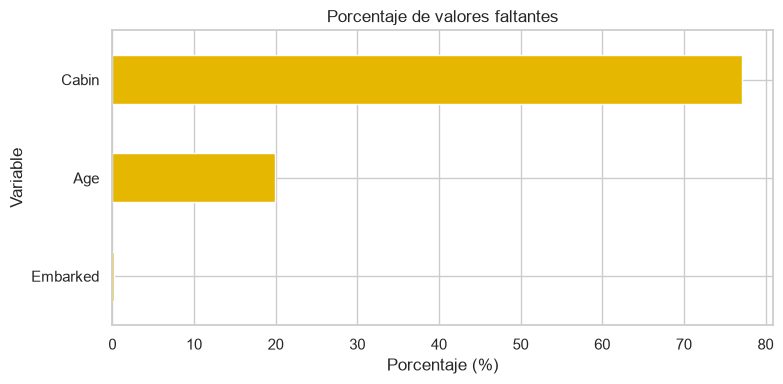

In [5]:
faltantes = (
    resumen_calidad.loc[resumen_calidad["faltantes"] > 0, ["faltantes", "faltantes_pct"]]
    .sort_values("faltantes_pct", ascending=False)
)
display(faltantes)

ax = faltantes["faltantes_pct"].sort_values().plot(
    kind="barh", figsize=(8, 4), color="#E5B700"
)
ax.set_title("Porcentaje de valores faltantes")
ax.set_xlabel("Porcentaje (%)")
ax.set_ylabel("Variable")
plt.tight_layout()
plt.show()

,cantidad,porcentaje
Survived,,
0,549,61.62
1,342,38.38


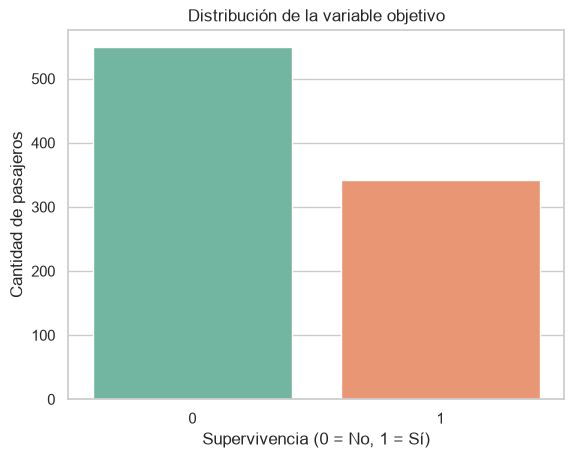

In [6]:
distribucion_objetivo = (
    train_df["Survived"]
    .value_counts()
    .sort_index()
    .rename_axis("Survived")
    .to_frame("cantidad")
)
distribucion_objetivo["porcentaje"] = (
    distribucion_objetivo["cantidad"] / len(train_df) * 100
).round(2)
display(distribucion_objetivo)

ax = sns.countplot(data=train_df, x="Survived", hue="Survived", legend=False)
ax.set_title("Distribución de la variable objetivo")
ax.set_xlabel("Supervivencia (0 = No, 1 = Sí)")
ax.set_ylabel("Cantidad de pasajeros")
plt.show()

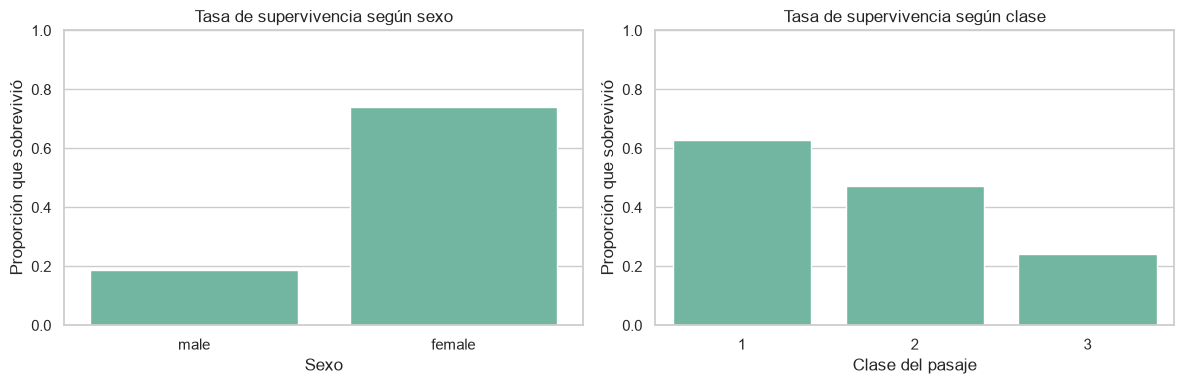

Survived,0,1
Sex,,
female,0.2580,0.7420
male,0.8111,0.1889


Survived,0,1
Pclass,,
1,0.3704,0.6296
2,0.5272,0.4728
3,0.7576,0.2424


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(data=train_df, x="Sex", y="Survived", ax=axes[0], errorbar=None)
axes[0].set_title("Tasa de supervivencia según sexo")
axes[0].set_xlabel("Sexo")
axes[0].set_ylabel("Proporción que sobrevivió")
axes[0].set_ylim(0, 1)

sns.barplot(data=train_df, x="Pclass", y="Survived", ax=axes[1], errorbar=None)
axes[1].set_title("Tasa de supervivencia según clase")
axes[1].set_xlabel("Clase del pasaje")
axes[1].set_ylabel("Proporción que sobrevivió")
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

display(pd.crosstab(train_df["Sex"], train_df["Survived"], normalize="index").round(4))
display(pd.crosstab(train_df["Pclass"], train_df["Survived"], normalize="index").round(4))

,count,mean,std,min,25%,50%,75%,max
Age,714.0,29.70,14.53,0.42,20.12,28.00,38.0,80.00
Fare,891.0,32.20,49.69,0.00,7.91,14.45,31.0,512.33
SibSp,891.0,0.52,1.10,0.00,0.00,0.00,1.0,8.00
Parch,891.0,0.38,0.81,0.00,0.00,0.00,0.0,6.00


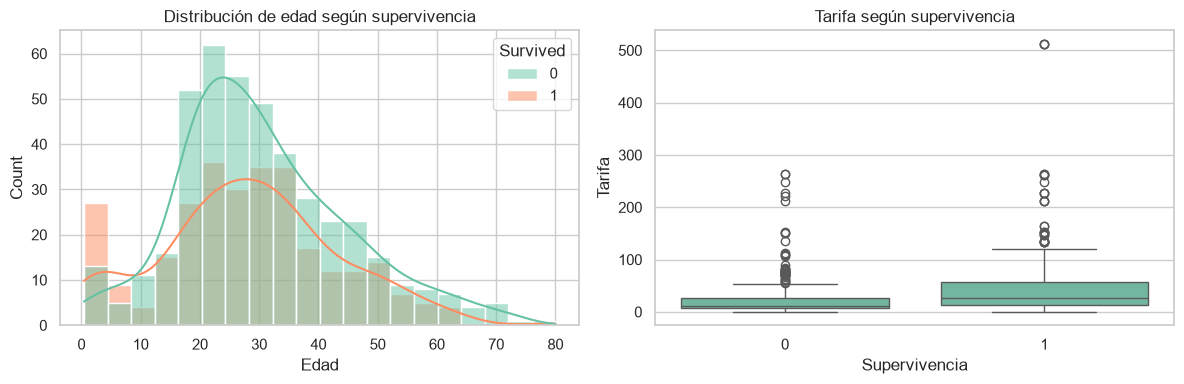

In [8]:
display(train_df[["Age", "Fare", "SibSp", "Parch"]].describe().T.round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(data=train_df, x="Age", hue="Survived", kde=True, ax=axes[0])
axes[0].set_title("Distribución de edad según supervivencia")
axes[0].set_xlabel("Edad")

sns.boxplot(data=train_df, x="Survived", y="Fare", ax=axes[1])
axes[1].set_title("Tarifa según supervivencia")
axes[1].set_xlabel("Supervivencia")
axes[1].set_ylabel("Tarifa")

plt.tight_layout()
plt.show()

In [9]:
def resumen_iqr(dataframe, columnas):
    resultados = []
    for columna in columnas:
        q1 = dataframe[columna].quantile(0.25)
        q3 = dataframe[columna].quantile(0.75)
        iqr = q3 - q1
        limite_inferior = q1 - 1.5 * iqr
        limite_superior = q3 + 1.5 * iqr
        mascara = (dataframe[columna] < limite_inferior) | (dataframe[columna] > limite_superior)
        resultados.append({
            "variable": columna,
            "Q1": q1,
            "Q3": q3,
            "límite_inferior": limite_inferior,
            "límite_superior": limite_superior,
            "observaciones_señaladas": int(mascara.sum()),
        })
    return pd.DataFrame(resultados).round(3)

display(resumen_iqr(train_df, ["Age", "Fare", "SibSp", "Parch"]))

,variable,Q1,Q3,límite_inferior,límite_superior,observaciones_señaladas
0,Age,20.125,38.0,-6.688,64.812,11
1,Fare,7.910,31.0,-26.724,65.634,116
2,SibSp,0.000,1.0,-1.500,2.500,46
3,Parch,0.000,0.0,0.000,0.000,213


### Interpretación inicial

- La variable `Age` contiene una proporción relevante de valores faltantes y requerirá imputación.
- `Cabin` presenta una ausencia muy elevada; en lugar de imputar cabinas específicas, se evaluará crear una característica indicadora como `HasCabin` o extraer la cubierta cuando esté disponible.
- `Embarked` contiene pocos valores faltantes y podrá tratarse mediante la moda calculada solamente con la muestra de entrenamiento.
- La variable objetivo no está perfectamente equilibrada, por lo que la separación estratificada ayudará a conservar su proporción.
- Los valores elevados de `Fare` pueden ser observaciones legítimas asociadas a pasajes de primera clase. El criterio IQR se utilizará para identificar casos, pero no para eliminarlos automáticamente.
- `SibSp` y `Parch` son recuentos discretos; una observación señalada por IQR no constituye necesariamente un error.

### Decisiones de limpieza y tratamiento

Las transformaciones que dependen de estadísticas de los datos se ajustarán **después de separar las muestras** y utilizando exclusivamente el conjunto de entrenamiento. Esto evita la fuga de información hacia validación o test.

| Situación | Tratamiento seleccionado | Justificación |
|---|---|---|
| Valores faltantes en `Age` | Imputación por mediana | Es robusta frente a valores extremos y se calcula solo con entrenamiento. |
| Valores faltantes en `Fare` | Imputación por mediana | Permite procesar también el archivo `test.csv`, que contiene un faltante. |
| Valores faltantes en `Embarked` | Imputación por moda | Es una variable categórica con muy pocos faltantes. |
| Alta ausencia en `Cabin` | Crear `HasCabin` y `Deck` | Conserva la señal de disponibilidad y cubierta sin inventar una cabina específica. |
| Asimetría y valores altos en `Fare` | Transformación `log1p` | Reduce la influencia de la cola derecha sin eliminar pasajeros válidos. |
| Valores altos de `Age` | Mantener | Corresponden a edades posibles y no se consideran errores de registro. |
| Valores altos de `SibSp` y `Parch` | Mantener y crear `FamilySize` | Son conteos familiares válidos; el criterio IQR no basta para eliminarlos. |
| `PassengerId`, `Ticket` y texto completo de `Name` | Excluir del modelo base | Presentan alta cardinalidad o funcionan principalmente como identificadores. |

## Punto 3. Ventanas de entrenamiento, validación y test

Se comparan tres alternativas para separar los datos:

| Método | Ventajas | Desventajas |
|---|---|---|
| División aleatoria simple | Es sencilla, rápida y apropiada cuando las observaciones son independientes. | Puede alterar la proporción de la variable objetivo entre muestras. |
| División aleatoria estratificada | Conserva la proporción de supervivientes y no supervivientes en entrenamiento, validación y test. | Requiere definir la variable usada para estratificar y no reemplaza una separación temporal cuando existe orden cronológico. |
| Validación cruzada estratificada | Usa varias particiones y entrega una evaluación más estable. | Tiene mayor costo computacional y conviene mantener, además, un test final no utilizado. |

### Método seleccionado
Se utilizará una **división aleatoria estratificada 70/15/15**, porque Titanic es un conjunto transversal, no temporal, y la variable `Survived` presenta una distribución de clases desigual. La semilla `random_state=42` asegura reproducibilidad. Como análisis complementario, se aplicará validación cruzada estratificada sobre la muestra de desarrollo.

In [10]:
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
)
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_score,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler

In [11]:
X_original = train_df.drop(columns="Survived")
y = train_df["Survived"]

# Primera separación: 70 % entrenamiento y 30 % temporal.
X_train_raw, X_temp_raw, y_train, y_temp = train_test_split(
    X_original,
    y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y,
)

# Segunda separación: el 30 % temporal se divide en 15 % validación y 15 % test.
X_valid_raw, X_test_raw, y_valid, y_test = train_test_split(
    X_temp_raw,
    y_temp,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=y_temp,
)

resumen_split = pd.DataFrame({
    "muestra": ["Entrenamiento", "Validación", "Test"],
    "observaciones": [len(y_train), len(y_valid), len(y_test)],
    "porcentaje_del_total": [len(y_train), len(y_valid), len(y_test)],
    "tasa_supervivencia": [y_train.mean(), y_valid.mean(), y_test.mean()],
})
resumen_split["porcentaje_del_total"] = (
    resumen_split["porcentaje_del_total"] / len(train_df) * 100
).round(2)
resumen_split["tasa_supervivencia"] = (
    resumen_split["tasa_supervivencia"] * 100
).round(2)
display(resumen_split)

assert len(y_train) + len(y_valid) + len(y_test) == len(train_df)
assert set(X_train_raw.index).isdisjoint(X_valid_raw.index)
assert set(X_train_raw.index).isdisjoint(X_test_raw.index)
assert set(X_valid_raw.index).isdisjoint(X_test_raw.index)

,muestra,observaciones,porcentaje_del_total,tasa_supervivencia
0,Entrenamiento,623,69.92,38.36
1,Validación,134,15.04,38.81
2,Test,134,15.04,38.06


### Ingeniería de características

Las siguientes transformaciones son determinísticas y no calculan estadísticas globales. Por eso pueden aplicarse de igual manera a entrenamiento, validación, test y a futuros datos de Kaggle.

In [12]:
def crear_variables(dataframe):
    resultado = dataframe.copy()

    # Extraer el tratamiento del nombre y agrupar títulos poco frecuentes.
    resultado["Title"] = (
        resultado["Name"]
        .str.extract(r",\s*([^.]*)\.", expand=False)
        .str.strip()
    )
    titulos_frecuentes = {"Mr", "Miss", "Mrs", "Master"}
    resultado["Title"] = resultado["Title"].where(
        resultado["Title"].isin(titulos_frecuentes),
        "Rare",
    )

    resultado["FamilySize"] = resultado["SibSp"] + resultado["Parch"] + 1
    resultado["IsAlone"] = (resultado["FamilySize"] == 1).astype(int)
    resultado["HasCabin"] = resultado["Cabin"].notna().astype(int)
    resultado["Deck"] = resultado["Cabin"].str[0].fillna("U")

    return resultado.drop(columns=["PassengerId", "Name", "Ticket", "Cabin"])

X_train = crear_variables(X_train_raw)
X_valid = crear_variables(X_valid_raw)
X_test = crear_variables(X_test_raw)

display(X_train.head())
print("Dimensiones después de crear variables:", X_train.shape)

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title,FamilySize,IsAlone,HasCabin,Deck
748,1,male,19.0,1,0,53.1000,S,Mr,2,0,1,D
45,3,male,NaN,0,0,8.0500,S,Mr,1,1,0,U
28,3,female,NaN,0,0,7.8792,Q,Miss,1,1,0,U
633,1,male,NaN,0,0,0.0000,S,Mr,1,1,0,U
403,3,male,28.0,1,0,15.8500,S,Mr,2,0,0,U


Dimensiones después de crear variables: (623, 12)


### Pipeline de limpieza y transformación

El `ColumnTransformer` aplica un tratamiento distinto según el tipo de variable. Los imputadores y escaladores se ajustan exclusivamente con `X_train`. La tarifa se transforma con `log1p` para reducir su asimetría sin eliminar observaciones legítimas.

In [13]:
variables_numericas = ["Age", "SibSp", "Parch", "FamilySize"]
variable_tarifa = ["Fare"]
variables_categoricas = [
    "Pclass", "Sex", "Embarked", "Title", "IsAlone", "HasCabin", "Deck"
]

pipeline_numerico = Pipeline(steps=[
    ("imputacion_mediana", SimpleImputer(strategy="median")),
    ("escalamiento", StandardScaler()),
])

pipeline_tarifa = Pipeline(steps=[
    ("imputacion_mediana", SimpleImputer(strategy="median")),
    ("logaritmo", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
    ("escalamiento", StandardScaler()),
])

pipeline_categorico = Pipeline(steps=[
    ("imputacion_moda", SimpleImputer(strategy="most_frequent")),
    ("one_hot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocesamiento = ColumnTransformer(transformers=[
    ("numericas", pipeline_numerico, variables_numericas),
    ("tarifa", pipeline_tarifa, variable_tarifa),
    ("categoricas", pipeline_categorico, variables_categoricas),
])

modelo = Pipeline(steps=[
    ("preprocesamiento", preprocesamiento),
    ("clasificador", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])

### Modelo base y evaluación en validación

La pauta se concentra en calidad y separación de datos. Sin embargo, se incorpora una regresión logística sencilla para demostrar que el pipeline es ejecutable de principio a fin. La muestra de test permanece intacta durante esta primera evaluación.

,métrica,valor
0,Accuracy,0.8881
1,Balanced accuracy,0.8839


              precision    recall  f1-score   support

           0     0.9136    0.9024    0.9080        82
           1     0.8491    0.8654    0.8571        52

    accuracy                         0.8881       134
   macro avg     0.8813    0.8839    0.8826       134
weighted avg     0.8885    0.8881    0.8882       134



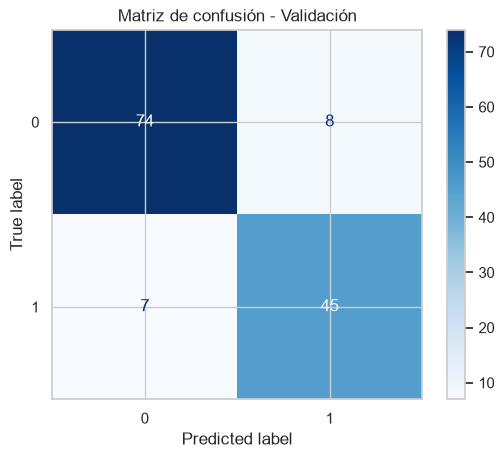

In [14]:
modelo.fit(X_train, y_train)
pred_valid = modelo.predict(X_valid)

metricas_validacion = pd.DataFrame({
    "métrica": ["Accuracy", "Balanced accuracy"],
    "valor": [
        accuracy_score(y_valid, pred_valid),
        balanced_accuracy_score(y_valid, pred_valid),
    ],
})
display(metricas_validacion.round(4))
print(classification_report(y_valid, pred_valid, digits=4))

ConfusionMatrixDisplay.from_predictions(y_valid, pred_valid, cmap="Blues")
plt.title("Matriz de confusión - Validación")
plt.show()

### Validación cruzada estratificada complementaria

Para comparar la estabilidad del pipeline se utiliza validación cruzada estratificada de cinco particiones sobre la muestra de entrenamiento. Las transformaciones se vuelven a ajustar dentro de cada fold, evitando fuga de información.

In [15]:
cv_estratificada = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)

scores_cv = cross_val_score(
    modelo,
    X_train,
    y_train,
    cv=cv_estratificada,
    scoring="balanced_accuracy",
)

display(pd.DataFrame({
    "fold": np.arange(1, len(scores_cv) + 1),
    "balanced_accuracy": scores_cv,
}).round(4))
print(f"Promedio CV: {scores_cv.mean():.4f}")
print(f"Desviación estándar CV: {scores_cv.std():.4f}")

,fold,balanced_accuracy
0,1,0.7463
1,2,0.8218
2,3,0.8061
3,4,0.8629
4,5,0.8109


Promedio CV: 0.8096
Desviación estándar CV: 0.0374


### Evaluación final en test interno

Después de revisar el resultado de validación, el modelo base se vuelve a ajustar usando entrenamiento más validación. El test interno se utiliza una sola vez para entregar una estimación final sin sesgo por selección.

In [16]:
X_desarrollo = pd.concat([X_train, X_valid], axis=0)
y_desarrollo = pd.concat([y_train, y_valid], axis=0)

modelo_final = clone(modelo)
modelo_final.fit(X_desarrollo, y_desarrollo)
pred_test = modelo_final.predict(X_test)

metricas_test = pd.DataFrame({
    "métrica": ["Accuracy", "Balanced accuracy"],
    "valor": [
        accuracy_score(y_test, pred_test),
        balanced_accuracy_score(y_test, pred_test),
    ],
})
display(metricas_test.round(4))
print(classification_report(y_test, pred_test, digits=4))

,métrica,valor
0,Accuracy,0.7910
1,Balanced accuracy,0.7746


              precision    recall  f1-score   support

           0     0.8235    0.8434    0.8333        83
           1     0.7347    0.7059    0.7200        51

    accuracy                         0.7910       134
   macro avg     0.7791    0.7746    0.7767       134
weighted avg     0.7897    0.7910    0.7902       134



### Interpretación del procedimiento

La división estratificada mantiene aproximadamente la misma tasa de supervivencia en las tres muestras. El pipeline evita la fuga de información porque los valores usados para imputar, escalar y codificar se aprenden durante `fit` únicamente con los datos disponibles en cada entrenamiento. La regresión logística funciona como una verificación técnica del proceso; el objetivo principal de esta unidad continúa siendo la calidad de los datos y la correcta construcción de las ventanas de desarrollo, validación y test.

## Punto 4. Repositorio, código y reproducibilidad

El proyecto se organiza en un repositorio local preparado para GitHub. Los datos originales se almacenan en `data/`, el análisis en `notebooks/`, las predicciones en `outputs/` y las dependencias en `requirements.txt`. Todas las rutas utilizadas son relativas, por lo que otro integrante puede clonar el repositorio y ejecutar el cuaderno sin modificar rutas personales.

```text
trabajo_machine_learning_titanic/
├── data/
│   ├── train.csv
│   ├── test.csv
│   └── gender_submission.csv
├── notebooks/
│   └── trabajo_titanic.ipynb
├── outputs/
│   └── submission_titanic.csv
├── .gitignore
├── README.md
└── requirements.txt
```

El archivo `README.md` explica el objetivo, la metodología, los resultados y los pasos de instalación y ejecución. El `.gitignore` evita publicar dependencias locales, cachés y archivos temporales.

**Enlace del repositorio GitHub:** https://github.com/CesarRR33/TRABAJOS-MACHINE-LEARNING-UMAYOR

### Predicción final para el archivo de Kaggle

Como producto adicional, el pipeline se ajusta con las 891 observaciones etiquetadas y genera una predicción para los 418 pasajeros de `test.csv`. Kaggle exige exactamente las columnas `PassengerId` y `Survived`. Este archivo demuestra que el proceso puede aplicarse a datos nuevos, aunque su envío a Kaggle no es obligatorio para responder la pauta.

In [17]:
X_completo = crear_variables(train_df.drop(columns="Survived"))
y_completo = train_df["Survived"]
X_kaggle = crear_variables(kaggle_test_df)

modelo_kaggle = clone(modelo)
modelo_kaggle.fit(X_completo, y_completo)
pred_kaggle = modelo_kaggle.predict(X_kaggle).astype(int)

submission_titanic = pd.DataFrame({
    "PassengerId": kaggle_test_df["PassengerId"],
    "Survived": pred_kaggle,
})

assert submission_titanic.shape == (418, 2)
assert submission_titanic.columns.tolist() == ["PassengerId", "Survived"]
assert set(submission_titanic["Survived"].unique()).issubset({0, 1})
assert submission_titanic["PassengerId"].equals(kaggle_test_df["PassengerId"])

OUTPUT_DIR = Path("../outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
ruta_submission = OUTPUT_DIR / "submission_titanic.csv"
submission_titanic.to_csv(ruta_submission, index=False)

display(submission_titanic.head())
print(f"Archivo generado: {ruta_submission.resolve()}")
print("Distribución predicha:")
display(submission_titanic["Survived"].value_counts().sort_index().to_frame("cantidad"))

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


Archivo generado: C:\Users\cesar\Documents\Codex\Proyecto\trabajo_machine_learning_titanic\outputs\submission_titanic.csv
Distribución predicha:


,cantidad
Survived,
0,249
1,169


## Conclusión

El desarrollo permitió construir un pipeline reproducible para analizar y preparar el conjunto Titanic. Entre CRISP-DM, KDD y SEMMA se seleccionó CRISP-DM porque integra la comprensión del problema, el análisis de los datos, la preparación, el modelamiento, la evaluación y el despliegue en un proceso iterativo.

La exploración identificó valores faltantes en `Age`, `Cabin` y `Embarked`, además de una fuerte asimetría en `Fare`. Los faltantes se trataron dentro del pipeline mediante mediana o moda, según el tipo de variable. La alta ausencia de `Cabin` se transformó en información mediante `HasCabin` y `Deck`. Los valores elevados no se eliminaron automáticamente: la tarifa se transformó con `log1p`, mientras que edades y conteos familiares válidos se conservaron.

Para Titanic se seleccionó una separación estratificada 70/15/15, obteniendo 623 observaciones de entrenamiento, 134 de validación y 134 de test, con una tasa de supervivencia cercana al 38 % en las tres muestras. Esta decisión fue más apropiada que una división aleatoria simple porque conservó la distribución de la variable objetivo. La validación cruzada estratificada complementó el análisis y obtuvo un `balanced accuracy` promedio de 0,8096.

La regresión logística se incorporó como comprobación del proceso completo. Alcanzó un accuracy de 0,8881 en validación y 0,7910 en el test interno final. La diferencia entre ambas muestras evidencia que una única partición puede producir resultados optimistas y refuerza la utilidad de la validación cruzada. El objetivo principal no fue maximizar la precisión, sino demostrar un tratamiento correcto, justificable y libre de fuga de información.

Finalmente, el pipeline fue ajustado sobre todas las observaciones etiquetadas para producir un archivo de 418 predicciones compatible con Kaggle. La estructura del repositorio, las rutas relativas y el registro de dependencias permiten que el análisis sea auditado y ejecutado nuevamente por otros integrantes.

## Bibliografía

- Fayyad, U., Piatetsky-Shapiro, G. y Smyth, P. (1996). *Knowledge Discovery and Data Mining: Towards a Unifying Framework*. AAAI Press. https://www.aaai.org/Papers/KDD/1996/KDD96-014.pdf
- IBM. (s. f.). *CRISP-DM Help Overview*. IBM SPSS Modeler Documentation. https://www.ibm.com/docs/en/spss-modeler/saas?topic=dm-crisp-help-overview
- Kaggle. (2012). *Titanic - Machine Learning from Disaster*. https://www.kaggle.com/competitions/titanic
- SAS Institute. (2012). *SEMMA: Sample, Explore, Modify, Model, Assess*. https://www.sas.com/content/dam/SAS/ru_ru/doc/academic/VMK_MGU/2015/lec5/EM2015_5.pdf
- Scikit-learn Developers. (s. f.). *ColumnTransformer*. https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html
- Scikit-learn Developers. (s. f.). *Pipeline*. https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html
- Scikit-learn Developers. (s. f.). *train_test_split*. https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html